In [1]:
import pandas as pd
from math import ceil
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf


df = pd.read_csv('../../Neuronales_Netz/Fahrradzaehlung_komplett_rolling_mean_int.csv',
                 sep=',')
df['time'] = pd.to_datetime(df['time'])
df['days'] = df['time'].dt.date

df = pd.DataFrame(df.groupby('days')['nordbruecke'].sum())
header = 'nordbruecke'

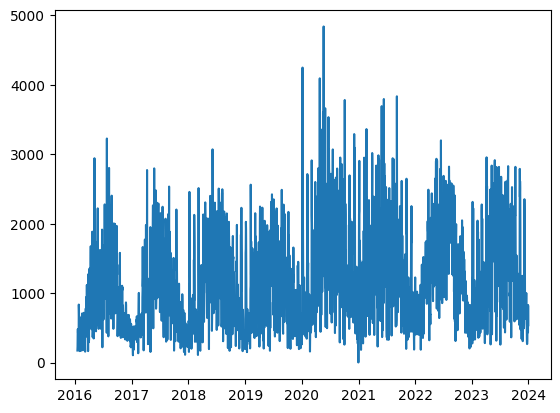

In [2]:
plt.plot(df[header])

In [3]:
df.index = pd.date_range(start=df.index[0], periods=len(df), freq='D')

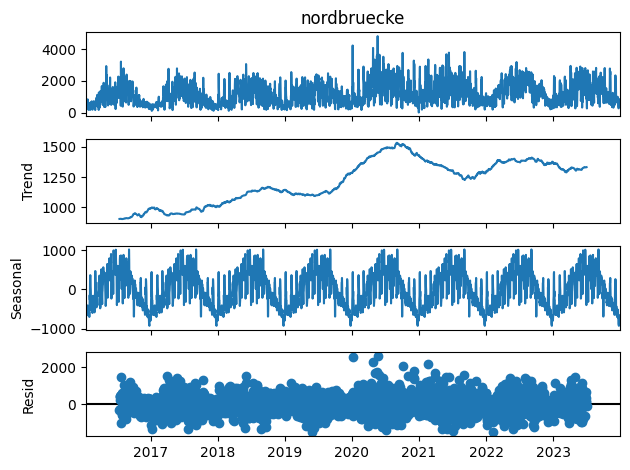

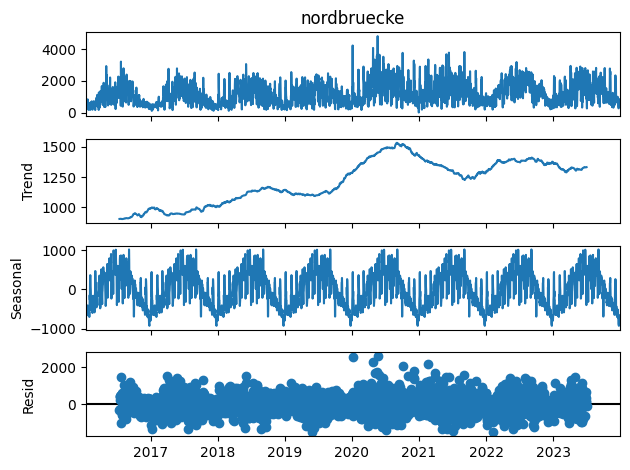

In [4]:
from statsmodels.tsa.seasonal import seasonal_decompose
decomposition = seasonal_decompose(df[header], period=365)
decomposition.plot()

In [5]:
from statsmodels.tsa.stattools import adfuller
result = adfuller(df[header])
print("Test statistic = {:.4f}".format(result[0]))
print("p-value = {:.4f}".format(result[1]))

Test statistic = -3.9221
p-value = 0.0019


In [6]:
#probiere logged first differences
from sklearn.preprocessing import MinMaxScaler
import numpy as np
maximum = max(df[header])
scaler = MinMaxScaler(feature_range=(1,maximum))
data = df[[header]]
model=scaler.fit(data)
scaled_data=model.transform(data)
df['scaled'] = scaled_data
df['log'] = np.log(df['scaled'])

In [7]:
#Aufteilung Trainings- und Testdaten

end_train = ceil(len(df) * 0.9)
df_train = df.iloc[:end_train]
df_test = df.iloc[end_train:]

In [8]:
df_train.loc[:,'differences'] = df_train.loc[:,header].diff(periods=365)
result = adfuller(df_train['differences'].dropna())
print("Test statistic = {:.4f}".format(result[0]))
print("P-value = {:.4f}".format(result[1]))

C:\Users\caddowallace\AppData\Local\Temp\ipykernel_6816\3224188387.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_train.loc[:,'differences'] = df_train.loc[:,header].diff(periods=365)


Test statistic = -7.6327
P-value = 0.0000


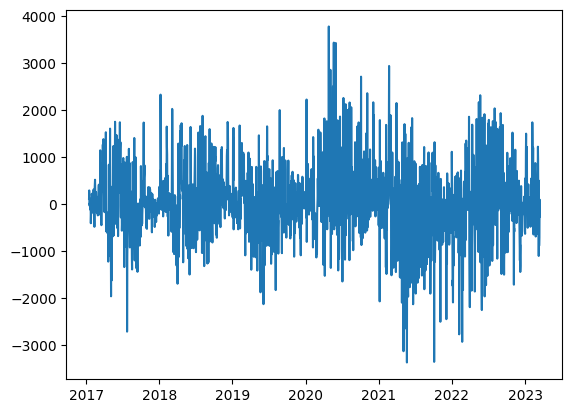

In [9]:
plt.plot(df_train.loc[:,'differences'] )

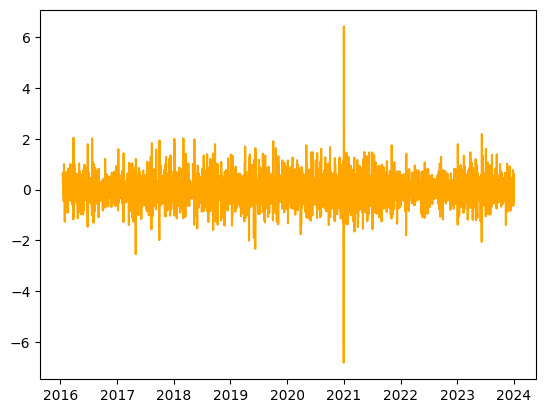

In [10]:
df['first_logged_diff'] = df['log'].diff().dropna()

plt.plot(df['first_logged_diff'], color='orange')
plt.show()

In [11]:
result = adfuller(df['first_logged_diff'].dropna())
print("Test statistic = {:.4f}".format(result[0]))
print("P-value = {:.4f}".format(result[1]))

Test statistic = -20.2572
P-value = 0.0000


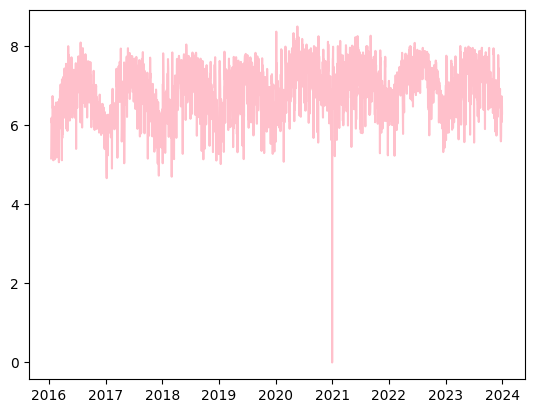

In [12]:
plt.plot(df['log'], color='pink')

In [13]:
df_train.index = pd.to_datetime(df_train.index)
df_train = df_train.asfreq('D')
df_test = df_test.asfreq('D')

from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_percentage_error
start_date= '2023-03-17'
end_date = '2023-12-31'
future_date='2024-02-28'
#Log Likelyhood: hoch, AIC: niedrig



Seasonal ARIMA

In [14]:
#Mittelwertbereinigung
df['days_noyear'] = pd.to_datetime(df.index).strftime('%m-%d')
df['day_mean'] = df.groupby('days_noyear')['log'].transform('mean')
df['cleaned_by_mean'] = df['log'] - df['day_mean']
display(df)

,nordbruecke,scaled,log,first_logged_diff,days_noyear,day_mean,cleaned_by_mean
2016-01-16,173,173.0,5.153292,NaN,01-16,6.387491,-1.234199
2016-01-17,230,230.0,5.438079,0.284788,01-17,6.183980,-0.745901
2016-01-18,442,442.0,6.091310,0.653231,01-18,6.386701,-0.295391
2016-01-19,483,483.0,6.180017,0.088707,01-19,6.282959,-0.102942
2016-01-20,425,425.0,6.052089,-0.127927,01-20,6.293187,-0.241098
...,...,...,...,...,...,...,...
2023-12-27,519,519.0,6.251904,-0.234257,12-27,6.172962,0.078942
2023-12-28,827,827.0,6.717805,0.465901,12-28,6.242056,0.475748
2023-12-29,434,434.0,6.073045,-0.644760,12-29,6.147379,-0.074334
2023-12-30,822,822.0,6.711740,0.638696,12-30,6.276366,0.435374


In [ ]:
df['weekday'] = df.index.dayofweek  # 0 = Montag, 6 = Sonntag
weekly_pattern = df.groupby('weekday')[header].mean()
print(weekly_pattern)

weekday
0    1194.033735
1    1261.337349
2    1273.380723
3    1212.260241
4    1145.604819
5    1050.456731
6    1271.533654
Name: nordbruecke, dtype: float64


In [ ]:
lags  = 7
plot_acf(df['cleaned_by_mean'], title='Autokorrelation, logarithmiert, um Mittelwert bereinigt', lags=lags)
plot_pacf(df['cleaned_by_mean'], title='Partielle Autokorrelation, logarithmiert, um Mittelwert bereinigt', lags=lags)
plt.show()
#für Order-Ebene, Lag 1 signifikant

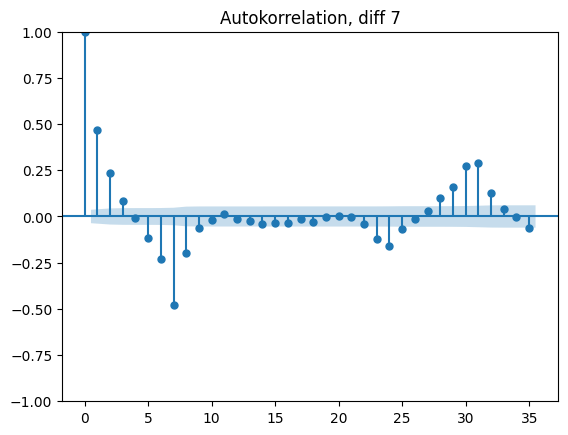

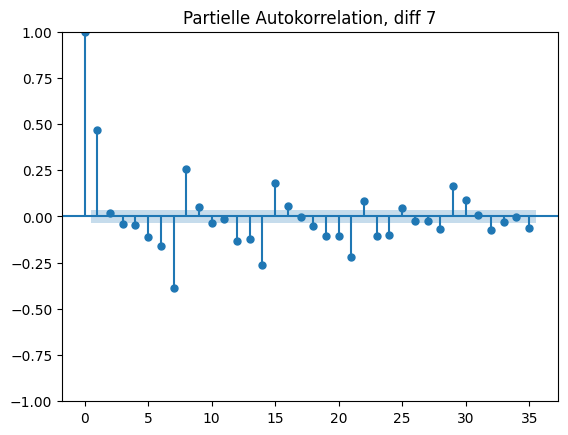

In [17]:
diffs = df[header].diff(periods=lags).dropna()
plot_acf(diffs[:], title='Autokorrelation, diff {:}'.format(lags))
plot_pacf(diffs[:], title='Partielle Autokorrelation, diff {:}'.format(lags))
plt.show()

In [18]:
#lags seasonal: 1, lag sonst: 1

end_train = ceil(len(df) * 0.8)
df_train_seas = df.iloc[:end_train]
df_test_seas = df.iloc[end_train:]

seasonal = 7
result1 = SARIMAX(df_train_seas['log'], order=(0, 0, 0),
                  seasonal_order=(0, 1, 0, seasonal)).fit()
result2 = SARIMAX(df_train_seas['log'], order=(0, 1, 0),
                  seasonal_order=(0, 1, 0, seasonal)).fit()
result3 = SARIMAX(df_train_seas['log'], order=(1, 0, 0),
                  seasonal_order=(0, 1, 1, seasonal)).fit()
result4 = SARIMAX(df_train_seas['log'], order=(1, 0, 0),
                  seasonal_order=(0, 1, 2, seasonal)).fit()
result5 = SARIMAX(df_train_seas['log'], order=(1, 1, 0),
                  seasonal_order=(0, 1, 2, seasonal)).fit()
result6 = SARIMAX(df_train_seas['log'], order=(0, 0, 1),
                  seasonal_order=(0, 1, 2, seasonal)).fit()
result7 = SARIMAX(df_train_seas['log'], order=(0, 1, 1),
                  seasonal_order=(0, 1, 2, seasonal)).fit()
result8 = SARIMAX(df_train_seas['log'], order=(0, 1, 1),
                  seasonal_order=(2, 1, 0, seasonal)).fit()
result9 = SARIMAX(df_train_seas['log'], order=(0, 1, 1),
                  seasonal_order=(1, 1, 0, seasonal)).fit()
result10 = SARIMAX(df_train_seas['log'], order=(0, 1, 1),
                  seasonal_order=(1, 1, 1, seasonal)).fit()

results = [result1, result2, result3, result4, result5, result6, result7, result8, result9, result10]
print('ARIMA (0,0,0)x(0,1,0,7) LL {:.4f}, AIC: {:.4f}'.format(result1.llf, result1.aic))
print('ARIMA (0,1,0)x(0,1,0,7) LL {:.4f}, AIC: {:.4f}'.format(result2.llf, result2.aic))
print('ARIMA (1,0,0)x(0,1,1,7) LL {:.4f}, AIC: {:.4f}'.format(result3.llf, result3.aic))
print('ARIMA (1,0,0)x(0,1,2,7) LL {:.4f}, AIC: {:.4f}'.format(result4.llf, result4.aic))
print('ARIMA (1,1,0)x(0,1,2,7) LL {:.4f}, AIC: {:.4f}'.format(result5.llf, result5.aic))
print('ARIMA (0,0,1)x(0,1,2,7) LL {:.4f}, AIC: {:.4f}'.format(result6.llf, result6.aic))
print('ARIMA (0,1,1)x(0,1,2,7) LL {:.4f}, AIC: {:.4f}'.format(result7.llf, result7.aic))
print('ARIMA (0,1,1)x(2,1,0,7) LL {:.4f}, AIC: {:.4f}'.format(result8.llf, result8.aic))
print('ARIMA (0,1,1)x(0,1,1,7) LL {:.4f}, AIC: {:.4f}'.format(result9.llf, result9.aic))
print('ARIMA (0,1,1)x(1,1,1,7) LL {:.4f}, AIC: {:.4f}'.format(result10.llf, result10.aic))


ARIMA (0,0,0)x(0,1,0,7) LL -2621.8012, AIC: 5245.6024
ARIMA (0,1,0)x(0,1,0,7) LL -2747.5602, AIC: 5497.1205
ARIMA (1,0,0)x(0,1,1,7) LL -1723.1025, AIC: 3452.2050
ARIMA (1,0,0)x(0,1,2,7) LL -1723.0830, AIC: 3454.1660
ARIMA (1,1,0)x(0,1,2,7) LL -1870.9497, AIC: 3749.8993
ARIMA (0,0,1)x(0,1,2,7) LL -1817.1609, AIC: 3642.3217
ARIMA (0,1,1)x(0,1,2,7) LL -1781.3534, AIC: 3570.7068
ARIMA (0,1,1)x(2,1,0,7) LL -2056.6019, AIC: 4121.2037
ARIMA (0,1,1)x(0,1,1,7) LL -2239.4406, AIC: 4484.8811
ARIMA (0,1,1)x(1,1,1,7) LL -1781.4040, AIC: 3570.8080


In [26]:
print(result3.summary())

                                      SARIMAX Results                                      
Dep. Variable:                                 log   No. Observations:                 2326
Model:             SARIMAX(1, 0, 0)x(0, 1, [1], 7)   Log Likelihood               -1723.103
Date:                             Mon, 10 Feb 2025   AIC                           3452.205
Time:                                     18:04:47   BIC                           3469.452
Sample:                                 01-16-2016   HQIC                          3458.490
                                      - 05-29-2022                                         
Covariance Type:                               opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.5219      0.010     49.980      0.000       0.501       0.542
ma.S.L7       -0.8788      

In [27]:
results_final = SARIMAX(df_train_seas['log'], order=(1, 0, 0),
                  seasonal_order=(0, 1, 1, seasonal)).fit()
y_pred_no_update = results_final.predict(start='2022-05-30', end='2024-03-30')
y_pred_no_update = pd.DataFrame(y_pred_no_update)
y_pred_no_update['unlogged'] = np.exp(y_pred_no_update['predicted_mean'])
y_pred_no_update['new_predict'] = scaler.inverse_transform(y_pred_no_update[['unlogged']])
print(y_pred_no_update)


            predicted_mean     unlogged  new_predict
2022-05-30        6.765266   867.197238   867.197238
2022-05-31        7.011561  1109.385285  1109.385285
2022-06-01        7.314623  1502.105513  1502.105513
2022-06-02        7.156532  1282.456157  1282.456157
2022-06-03        7.002361  1099.225197  1099.225197
...                    ...          ...          ...
2024-03-26        7.180847  1314.020227  1314.020227
2024-03-27        7.402979  1640.865974  1640.865974
2024-03-28        7.202649  1342.983466  1342.983466
2024-03-29        7.026431  1126.004468  1126.004468
2024-03-30        7.075249  1182.337802  1182.337802

[671 rows x 3 columns]


Text(0.5, 1.0, 'Prognose')

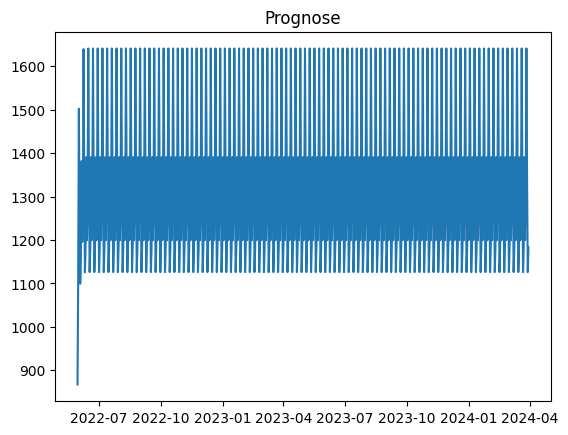

In [28]:
plt.plot(y_pred_no_update['new_predict'])
plt.title('Prognose')

Text(0.5, 1.0, 'tatsächliche Daten')

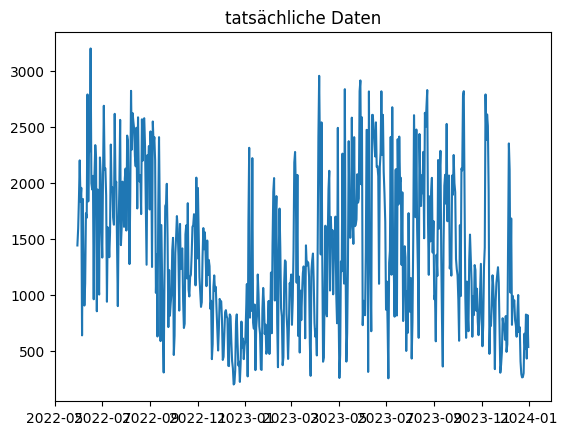

In [29]:
plt.plot(df_test_seas[header])
plt.title('tatsächliche Daten')

In [33]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

arima = SARIMAX(df_train_seas['log'], order=(1, 0, 0),
                  seasonal_order=(0, 1, 1, seasonal), freq='D')
result = arima.fit()
#print(result.summary())
model = SARIMAX(df['log'], order=(1, 0, 0),
                  seasonal_order=(0, 1, 1, seasonal), freq='D')
result_new = model.filter(result.params)
y_pred_test = result_new.predict(start='2022-05-30', end='2024-12-31')

tmp = pd.DataFrame(y_pred_test)
tmp['unlogged'] = np.exp(tmp['predicted_mean'])
tmp['final_data'] = scaler.inverse_transform(tmp[['unlogged']])

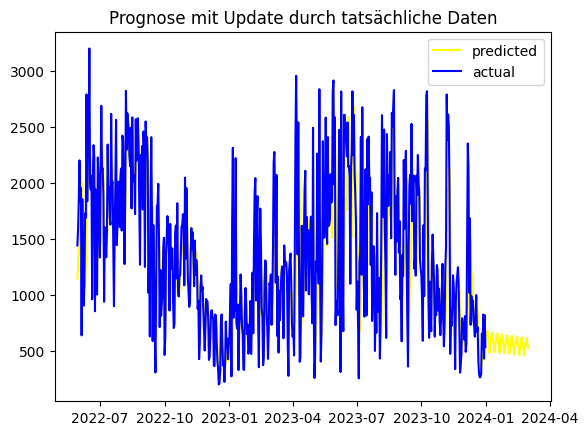

In [34]:
# Mergen der Daten
df_r = pd.concat([df_train_seas, tmp], axis=1)

df_r[header] = df_r[header].fillna(df_r['final_data'])
df_r = pd.DataFrame(df_r)
df_r.index = pd.to_datetime(df_r.index)
start_date = '2022-05-30'
end_date = '2024-03-01'
plt.title('Prognose mit Update durch tatsächliche Daten')
plt.plot(df_r.loc[start_date:end_date, 'final_data'],
            color='yellow', label='predicted')
plt.plot(df.loc[start_date:'2023-12-31', header], color='blue', label='actual')
plt.legend()
plt.show()

In [35]:
mape_bound = 100

df_test_seas.loc[:,'intervals'] = (df_test_seas[header] > mape_bound).astype(int).diff().fillna(0).ne(0).cumsum()
df_test_seas.loc[:,'group'] = df_test_seas[header].apply(lambda x: '≤ 10' if x <= mape_bound else '> 10')
df_test_seas.loc[:,'predicted'] = df_r.loc[start_date:end_date, header]

greater = df_test_seas[df_test_seas['group'] == '> 10']
mape_arima = []
mape_simple = []

for name, group in greater.groupby('intervals'):
    mape_arima.append(mean_absolute_percentage_error(group[header], group['predicted']))

mae_arima = np.mean(np.abs(df_test_seas[header] - df_r.loc[start_date:'2023-12-31', header]))
mse_arima = np.mean(np.square(df_test_seas[header] - df_r.loc[start_date:'2023-12-31', header]))
mape_arima = sum(mape_arima)/len(mape_arima)


print("mean absolute error (mae): ARIMA: {:.4f}".format(mae_arima))
print("mean squared error (mse): ARIMA: {:.4f}".format(mse_arima))
print("mean absolute percentage error (mape): ARIMA: {:.4f}".format(mape_arima))

mean absolute error (mae): ARIMA: 416.5860
mean squared error (mse): ARIMA: 297162.0420
mean absolute percentage error (mape): ARIMA: 0.3901
